In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

In [10]:
PATH = "../dataset/"

TRAIN_FRESH = os.path.join(PATH, "freshoranges")
TRAIN_ROTTEN = os.path.join(PATH, "rottenoranges")

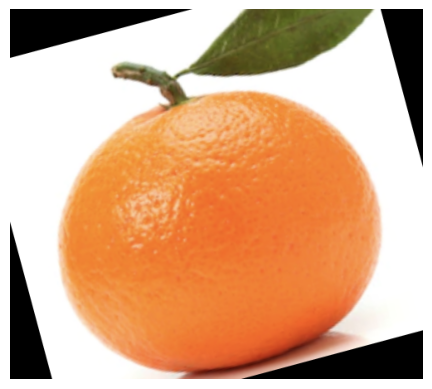

In [11]:
arquivo = os.listdir(TRAIN_FRESH)[0]

img = cv2.imread(os.path.join(TRAIN_FRESH, arquivo))
img_rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis("off")
plt.show()

In [14]:
def desenhar_contorno(bgr, mask):
    imagem_contorno = bgr.copy()

    contornos, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    cv2.drawContours(
        imagem_contorno,
        contornos,
        -1,
        (0, 255, 0),
        2
    )

    return imagem_contorno

In [12]:
print("Fresh:", len(os.listdir(TRAIN_FRESH)))
print("Rotten:", len(os.listdir(TRAIN_ROTTEN)))
print(img_rgb.shape)

Fresh: 1466
Rotten: 1595
(446, 498, 3)


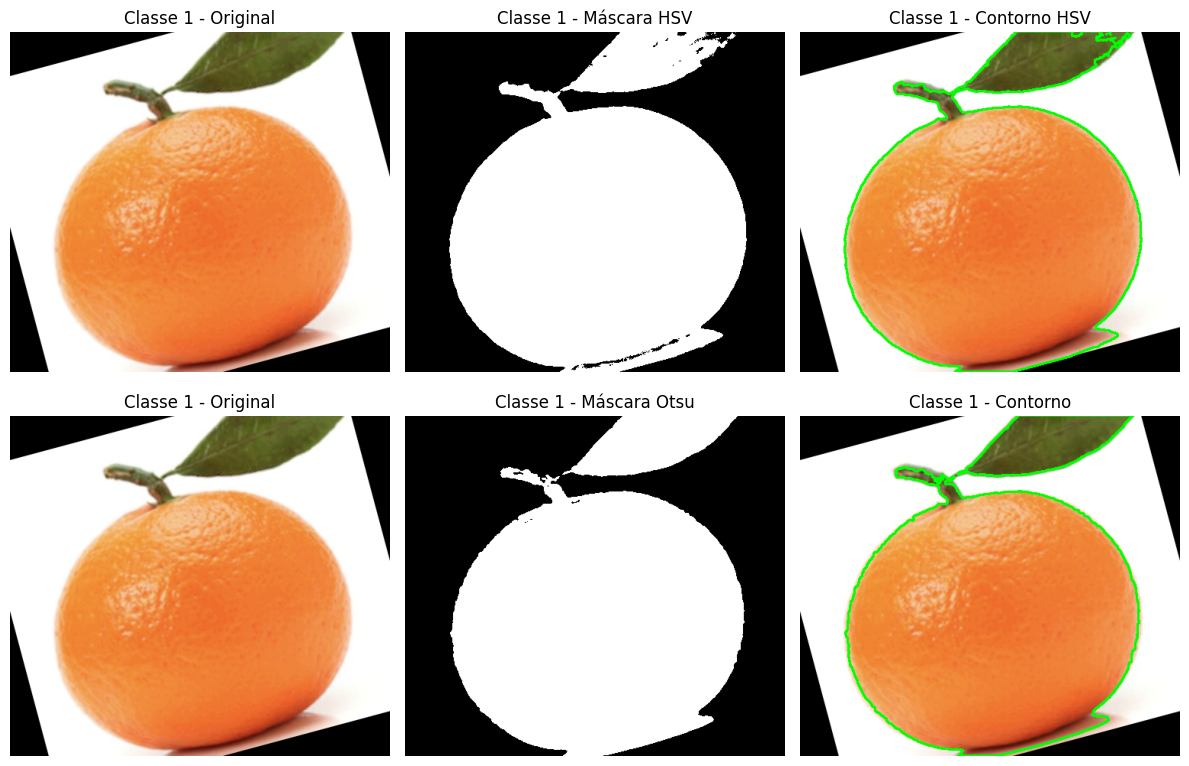

In [25]:
img_hsv = cv2.cvtColor(img_rgb,cv2.COLOR_RGB2HSV)

lower = np.array([5, 50, 50])
upper = np.array([35, 255, 255])

mask_hsv = cv2.inRange(img_hsv,lower,upper)


fig, axes = plt.subplots(2, 3, figsize=(12, 8))

sat = img_hsv[...,1]

_, mask_otsu = cv2.threshold(sat,0,255,cv2.THRESH_BINARY + cv2.THRESH_OTSU)


axes[0,0].imshow(cv2.cvtColor(img_hsv,cv2.COLOR_HSV2RGB))
axes[0, 0].set_title("Classe 1 - Original")
axes[0, 0].axis("off")

axes[0, 1].imshow(mask_hsv, cmap="gray") 
axes[0, 1].set_title("Classe 1 - Máscara HSV")
axes[0, 1].axis("off")

axes[0, 2].imshow(cv2.cvtColor(desenhar_contorno(cv2.cvtColor(img_hsv,cv2.COLOR_HSV2BGR), mask_hsv), cv2.COLOR_BGR2RGB))
axes[0, 2].set_title("Classe 1 - Contorno HSV")
axes[0, 2].axis("off")


axes[1,0].imshow(cv2.cvtColor(img_hsv,cv2.COLOR_HSV2RGB))
axes[1, 0].set_title("Classe 1 - Original")
axes[1, 0].axis("off")

axes[1, 1].imshow(mask_otsu, cmap="gray") 
axes[1, 1].set_title("Classe 1 - Máscara Otsu")
axes[1, 1].axis("off")

axes[1, 2].imshow(cv2.cvtColor(desenhar_contorno(cv2.cvtColor(img_hsv,cv2.COLOR_HSV2BGR), mask_otsu), cv2.COLOR_BGR2RGB))
axes[1, 2].set_title("Classe 1 - Contorno")
axes[1, 2].axis("off")
# plt.figure(figsize=(6,6))
# plt.imshow(mask, cmap="gray")
plt.axis("off")
plt.tight_layout()
plt.show()

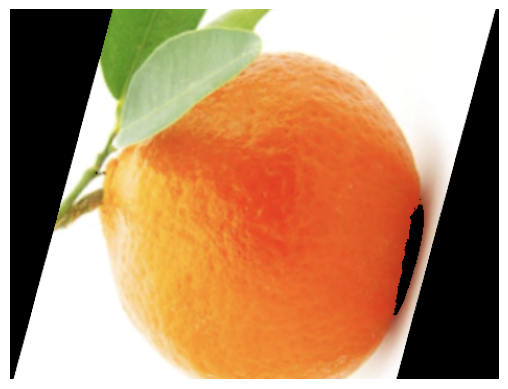

In [19]:
resultado_otsu = cv2.bitwise_and(img_rgb,img_rgb,mask=mask_otsu)

plt.imshow(resultado_otsu)
plt.axis("off")
plt.show()

In [46]:
def compare_segmentation(img_rgb, titulo=""):

    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

    lower = np.array([5, 50, 50])
    upper = np.array([35, 255, 255])

    mask_hsv = cv2.inRange(hsv, lower, upper)

    sat = hsv[...,1]
    _, mask_otsu = cv2.threshold(gray,0,255,cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))

    axes[0,0].imshow(cv2.cvtColor(hsv,cv2.COLOR_HSV2RGB))
    axes[0, 0].set_title("Classe 1 - Original")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(mask_hsv, cmap="gray") 
    axes[0, 1].set_title("Classe 1 - Máscara HSV")
    axes[0, 1].axis("off")

    axes[0, 2].imshow(cv2.cvtColor(desenhar_contorno(cv2.cvtColor(hsv,cv2.COLOR_HSV2BGR), mask_hsv), cv2.COLOR_BGR2RGB))
    axes[0, 2].set_title("Classe 1 - Contorno HSV")
    axes[0, 2].axis("off")


    axes[1,0].imshow(cv2.cvtColor(hsv,cv2.COLOR_HSV2RGB))
    axes[1, 0].set_title("Classe 1 - Original")
    axes[1, 0].axis("off")

    axes[1, 1].imshow(mask_otsu, cmap="gray") 
    axes[1, 1].set_title("Classe 1 - Máscara Otsu")
    axes[1, 1].axis("off")

    axes[1, 2].imshow(cv2.cvtColor(desenhar_contorno(cv2.cvtColor(hsv,cv2.COLOR_HSV2BGR), mask_otsu), cv2.COLOR_BGR2RGB))
    axes[1, 2].set_title("Classe 1 - Contorno")
    axes[1, 2].axis("off")
    # plt.figure(figsize=(6,6))
    # plt.imshow(mask, cmap="gray")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


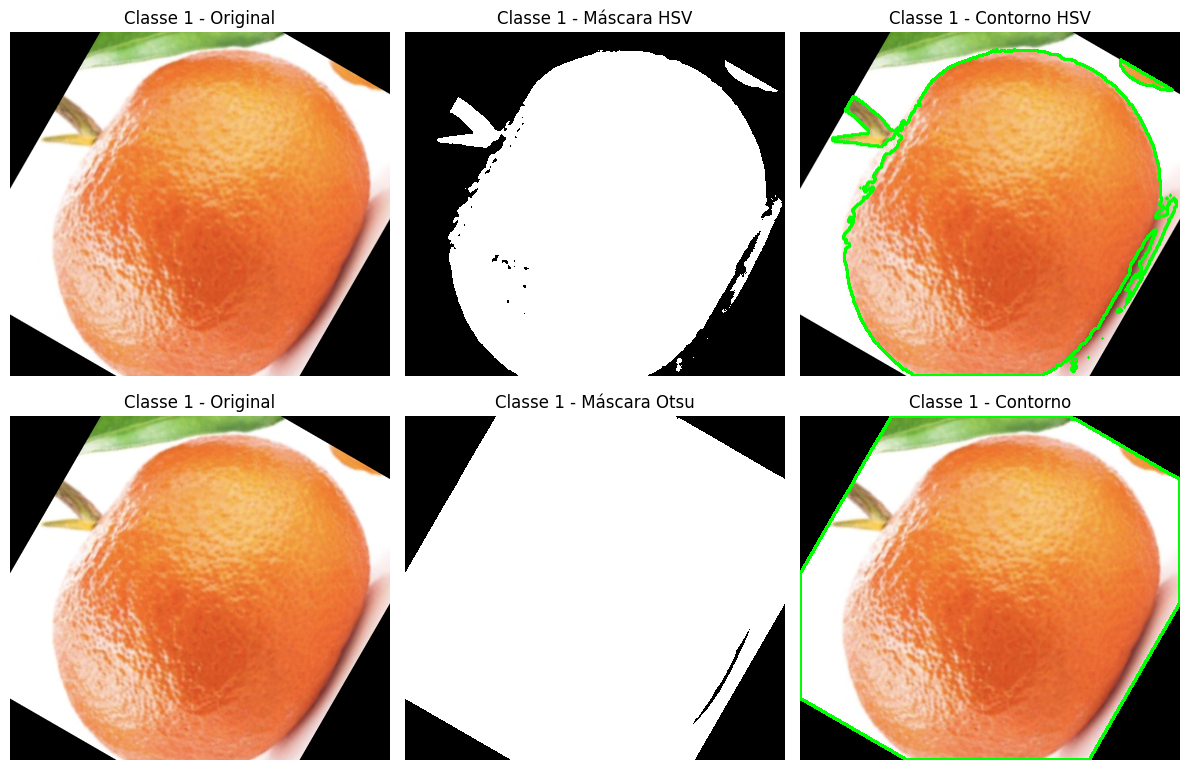

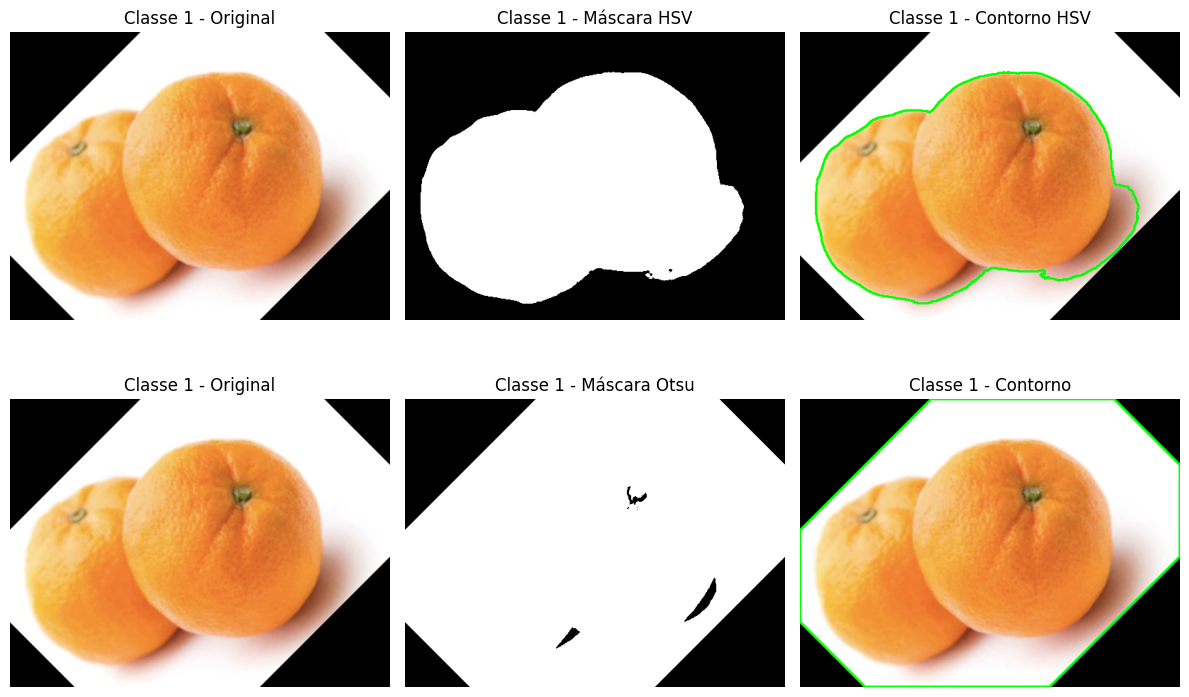

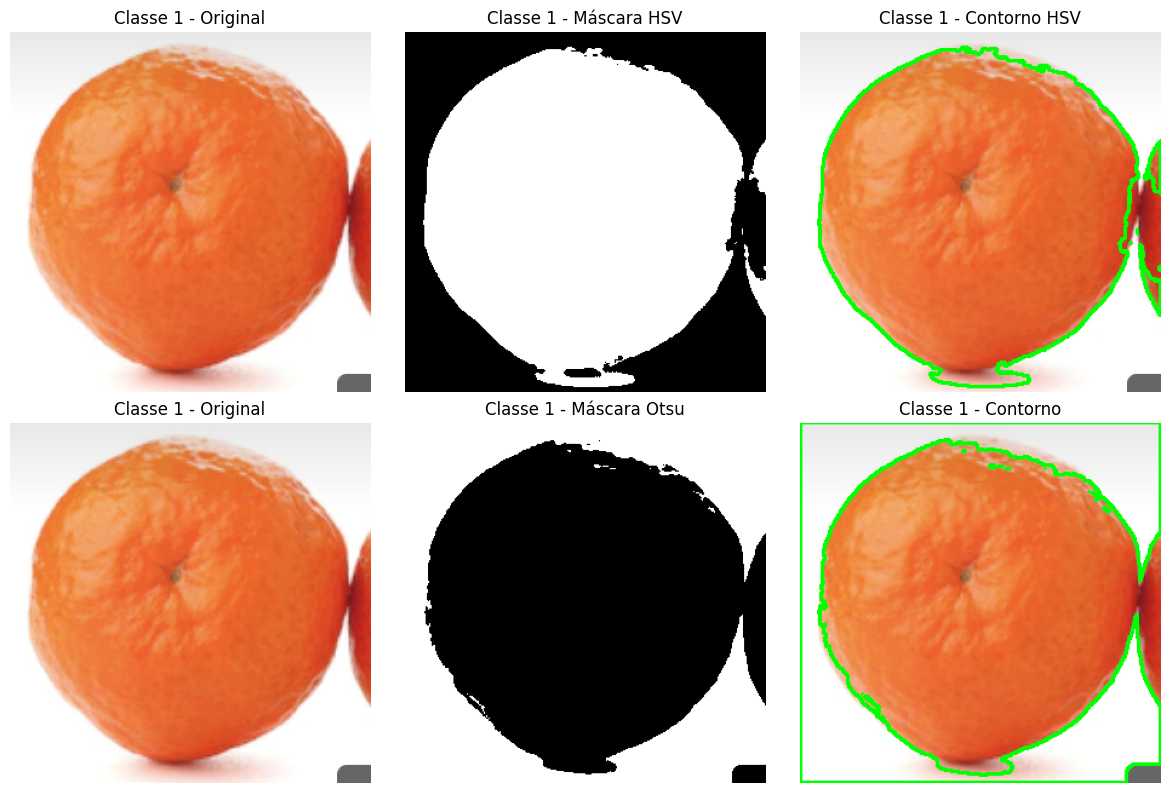

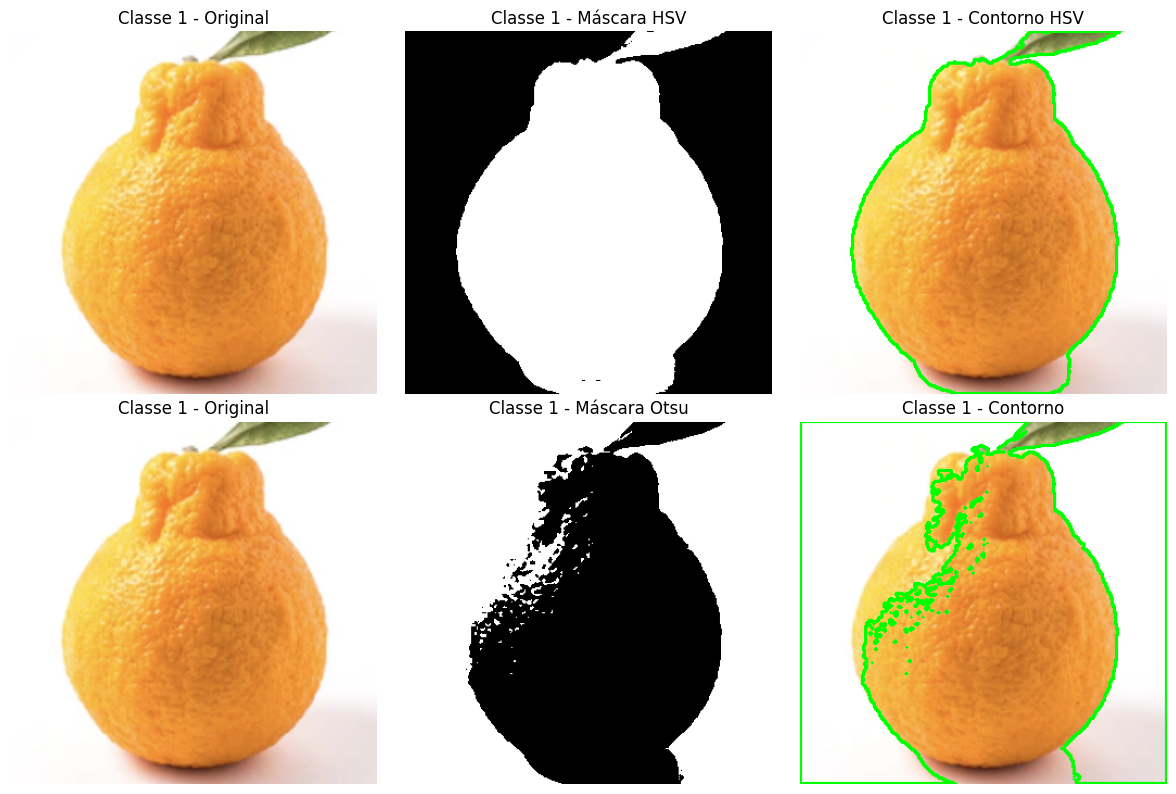

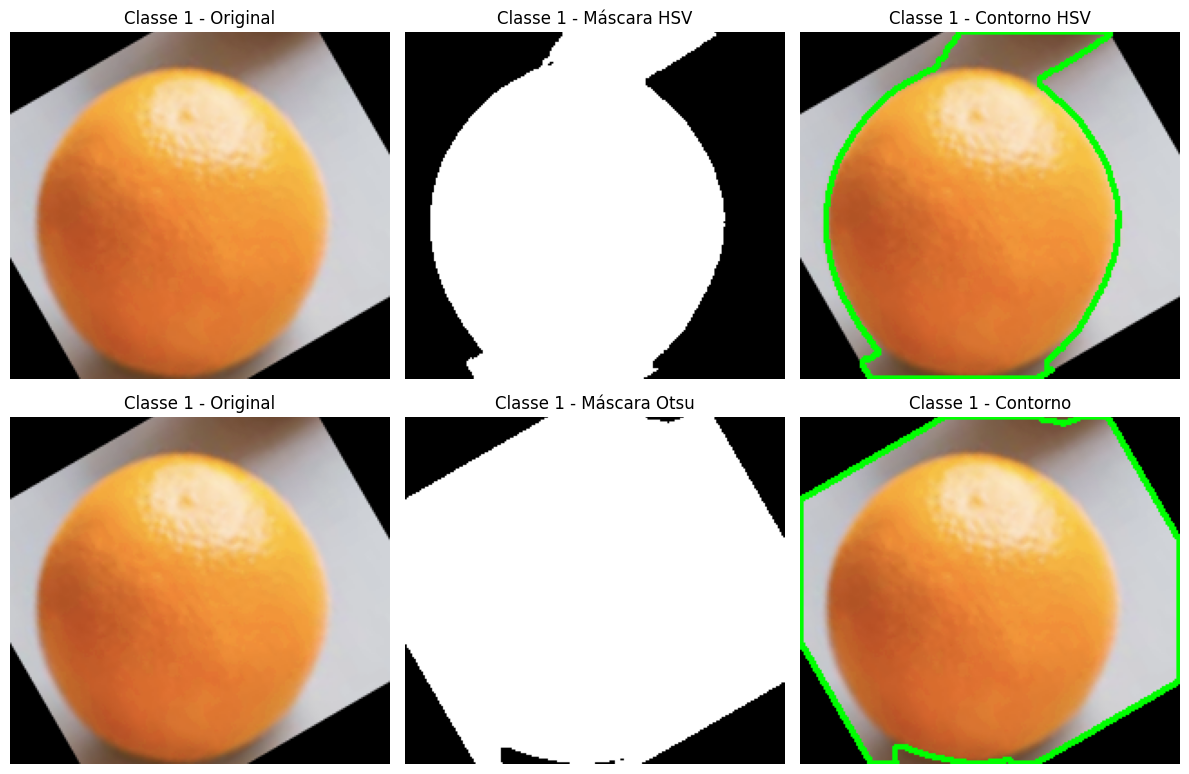

In [47]:
fresh_samples = random.sample(os.listdir(TRAIN_FRESH),5)

for arquivo in fresh_samples:
    img = cv2.imread(os.path.join(TRAIN_FRESH, arquivo))
    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    compare_segmentation(img,"Fresh Orange")

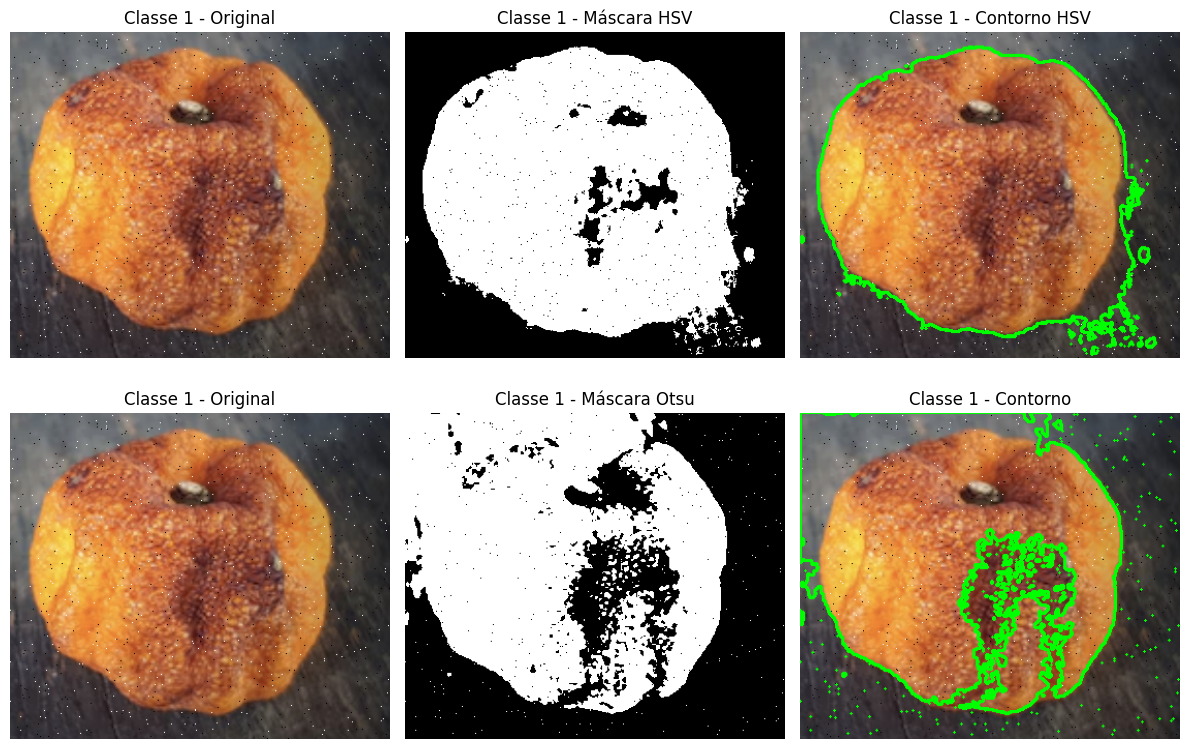

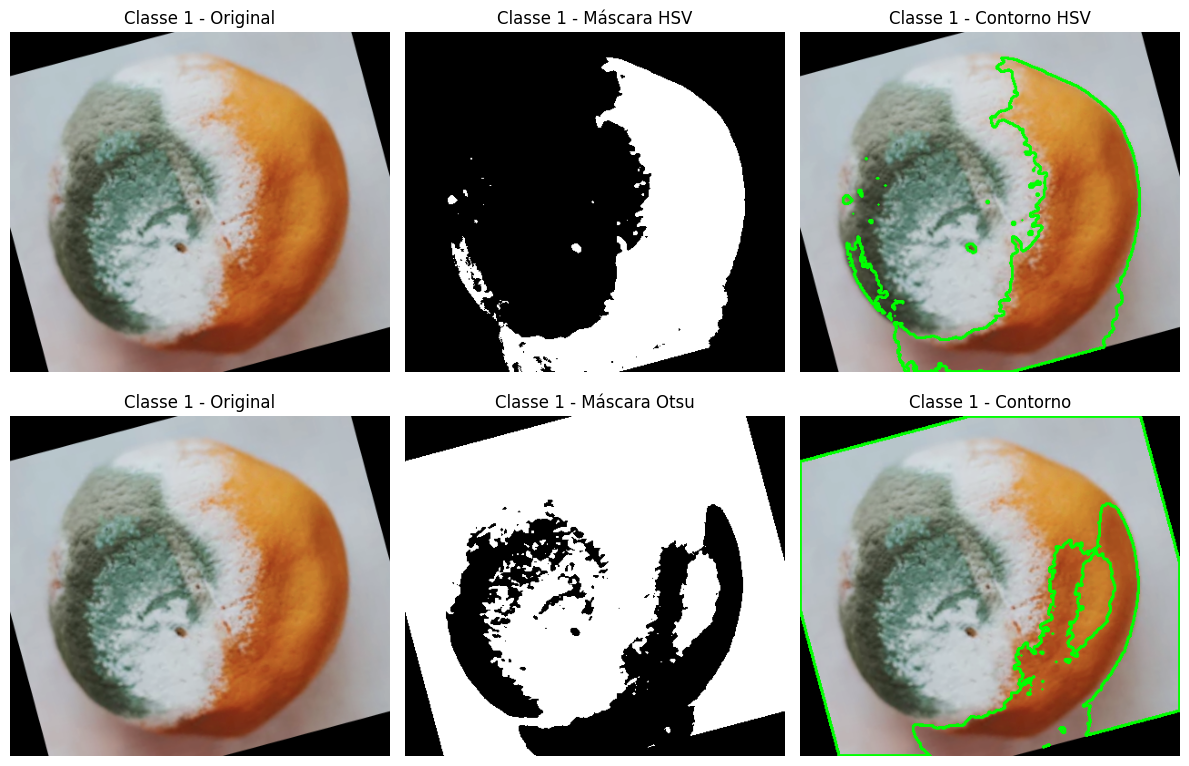

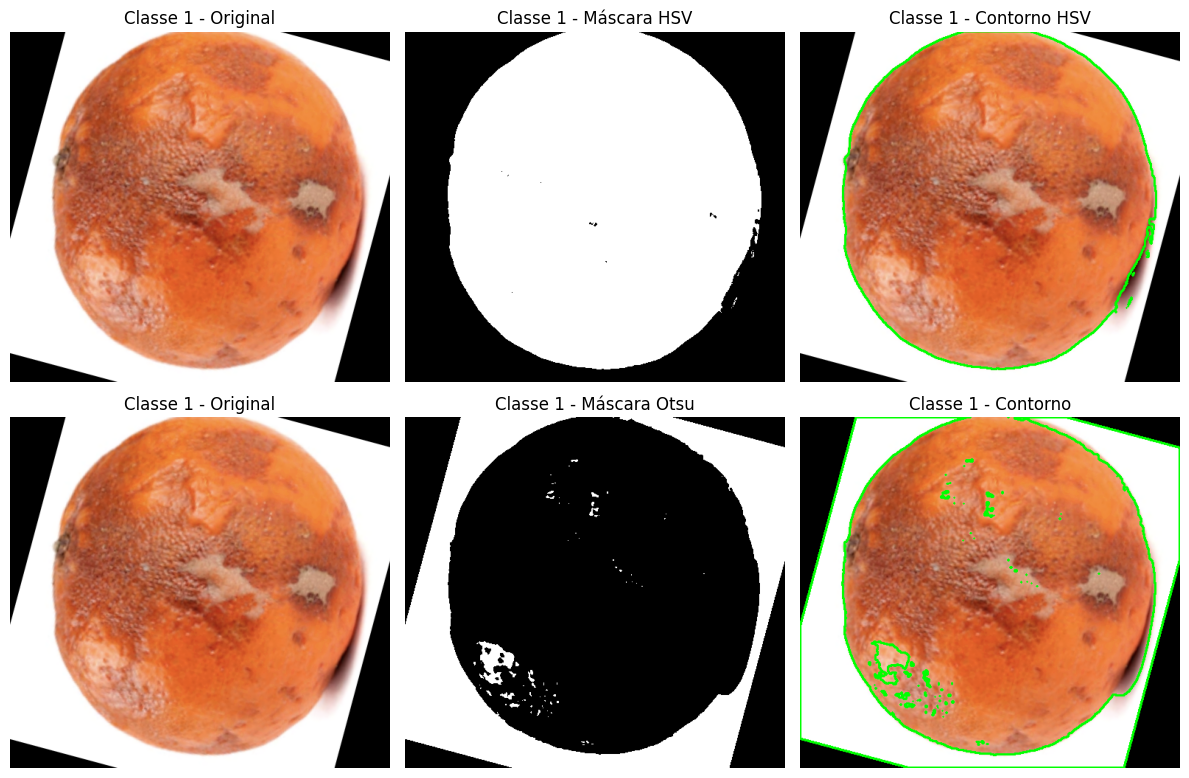

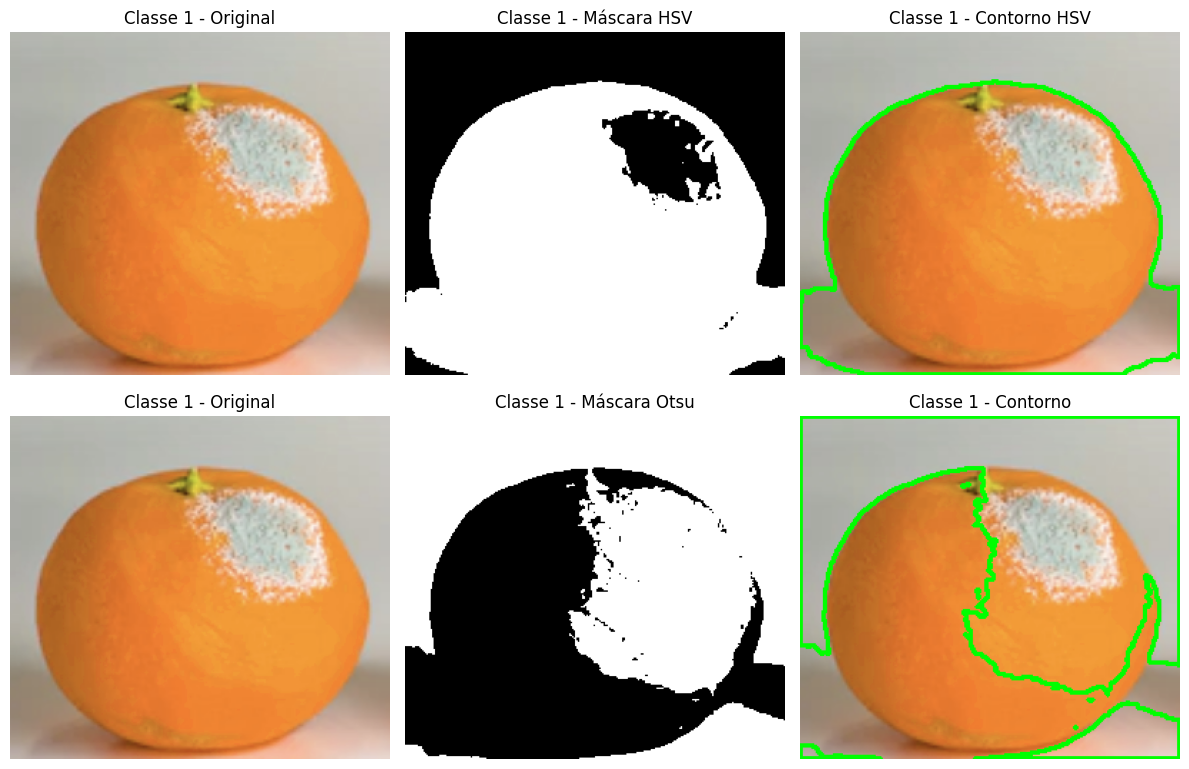

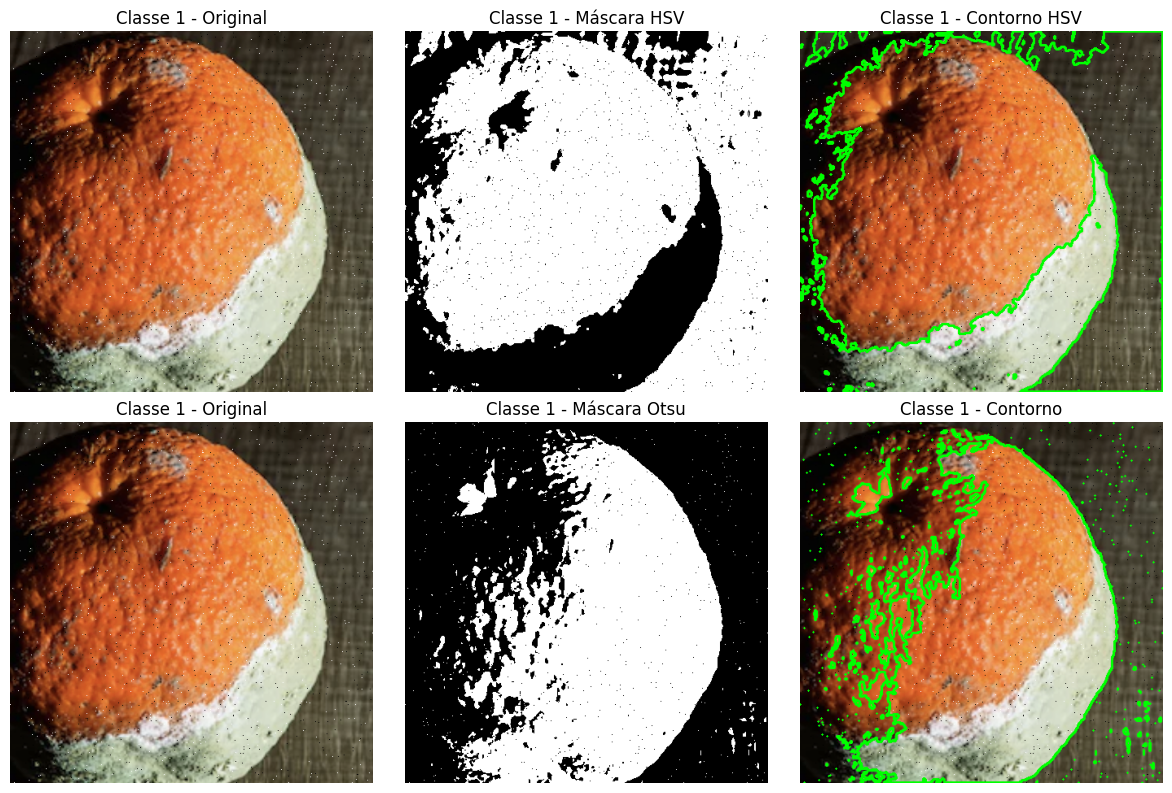

In [49]:
rotten_samples = random.sample(os.listdir(TRAIN_ROTTEN),5)

for arquivo in rotten_samples:
    img = cv2.imread(os.path.join(TRAIN_ROTTEN, arquivo))
    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    compare_segmentation(img,"Rotten Orange")